# 202.1. Deep coadds

<div style="max-width:300px; float: left; margin-right: 1em">

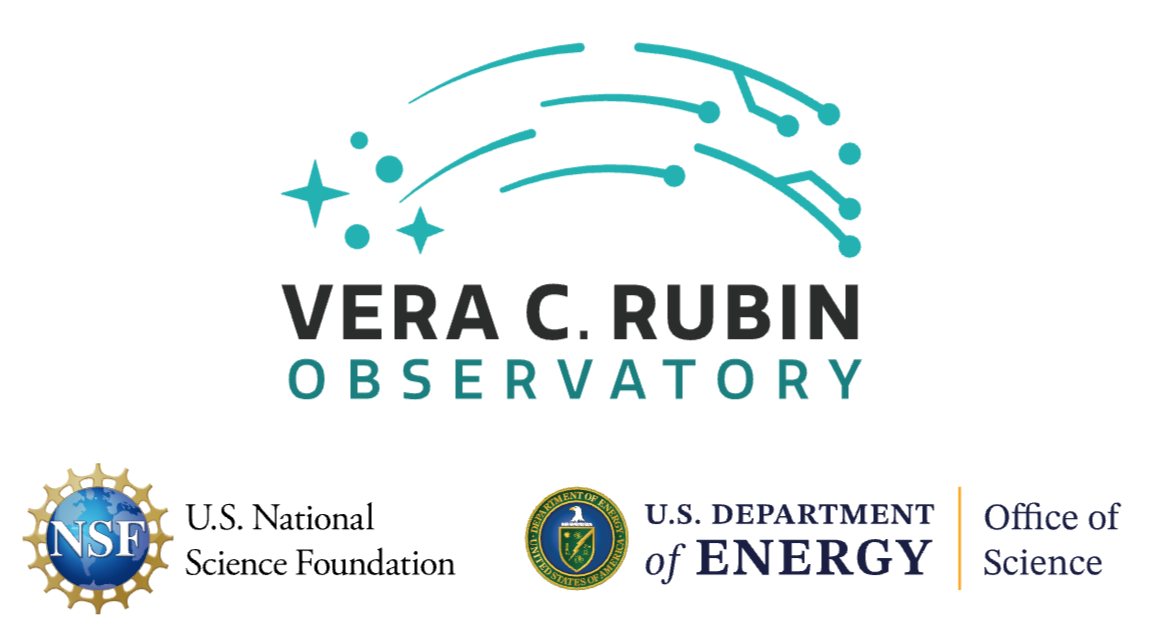

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp2.lsst.io/">Data Preview 2</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r30.0.10 <br>
Last verified to run: 2026-07-23 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>

**Learning objective:** To understand the format and metadata of a `deep_coadd`.

**LSST data products:** `deep_coadd`

**Packages:** `lsst.daf.butler`, `lsst.rsp`, `lsst.afw.display`

**Credit:**
Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

A `deep_coadd` is a combination of multiple processed, calibrated, and background-subtracted images, for a patch of sky, for one of the six LSST filters.

* butler dataset type: `deep_coadd`
* number of images: 925460

**Related tutorials:** The 100-level tutorials on how to use the Butler, TAP, SIA, Firefly, and the cutout service demonstrate how to query for and retrieve images, how to create small image cutouts ("stamps"), and how to manipulate the Firefly display interface.

### 1.1. Import packages

From the LSST Science Pipelines import the packages for the Butler, 2-dimensional sky geometry, and for image display.
Also import the `numpy` package, `matplotlib` plotting tools, and `Astropy` coordinate utilities.

In [ ]:
from lsst.daf.butler import Butler
import lsst.afw.display as afwDisplay
from lsst.images._cell_grid import CellIJ

from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
import numpy as np

### 1.2. Define parameters and functions

Instantiate the Butler.

In [ ]:
butler = Butler('dp2', collections=["dp2"])

Set `afw_display` to use `Firefly` and open the Firefly display tab.

In [ ]:
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

## 2. Data access

It is recommended to use the Rubin data `Butler` to retrieve image data within Jupyter Notebooks,
but they are also available via the TAP and SIA services (Table Access Protocol and Simple Image Access).

**Recommended access method:** Butler

### 2.1. Butler

Show that the dimensions for the `deep_coadd` dataset type are the band, and the skymap's tract and patch, and that the returned image will be of type `CellCoadd`. 
The LSST Science Pipelines tools for image manipulation and visualization work best with the `CellCoadd` format.
This format includes pixel data and metadata.

In [ ]:
butler.get_dataset_type('deep_coadd')

In [ ]:
butler.get_dataset_type('deep_coadd').dimensions.required

#### 2.1.1. Demo query

Query for `deep_coadd` imges that overlap coordinates RA, Dec near the center of the ECDFS field and were obtained with the $r$-band filter.

In [ ]:
ra = 53.076
dec = -28.110
band = 'r'
dataset_refs = butler.query_datasets("deep_coadd",
                                     where="band.name = :band AND \
                                     patch.region OVERLAPS POINT(:ra, :dec)",
                                     bind={"band": band, "ra": ra, "dec": dec})

print(len(dataset_refs))
del band

The query returns only a single $r$-band `deep_coadd` image overlapping the RA, Dec coordinates.

#### 2.1.2. Get an image

The `deep_coadd` can be retrieved from the Butler using the
(a) the `dataset_refs`; (b) the `dataId`; or (c) the `tract` and `patch` numbers.

##### (a) Use the dataset reference

For the first dataset reference returned by the query, get the corresponding `deep_coadd`.

In [ ]:
ref = dataset_refs[0]
deep_coadd = butler.get(ref)

See that it is of type `CellCoadd`.

In [ ]:
deep_coadd

Display the image in the Firefly window.
Set the mask transparency to 100 (fully transparent, i.e., do not show the mask).

In [ ]:
afw_display.mtv(deep_coadd)
afw_display.setMaskTransparency(100)

Clean up.

In [ ]:
del ref

##### (b) Use the dataId

For the first dataset reference returned by the query, get the `dataId`.

In [ ]:
ref = dataset_refs[0]
use_dataId = ref.dataId
use_dataId

Option to use the defined `dataId` to retrieve the corresponding `deep_coadd`.

In [ ]:
# deep_coadd = butler.get('deep_coadd', dataId = use_dataId)

Option to display the `deep_coadd`.

In [ ]:
# afw_display.mtv(deep_coadd)

Clean up.

In [ ]:
del ref, use_dataId

##### (c) Use the tract, patch, band, and skymap

For the first dataset reference returned by the query, get the `dataId` and extract the `band`, the `tract` and `patch` numbers, and the `skymap`.

In [ ]:
ref = dataset_refs[0]
dataId = ref.dataId
use_band = dataId.get('band')
use_tract = dataId.get('tract')
use_patch = dataId.get('patch')
use_skymap = dataId.get('skymap')
print(use_band, use_tract, use_patch, use_skymap)

Even if the Butler is not used to *query* for the images (e.g., if the SIA or TAP service is used to find images matching a set of constraints),
images can be retrieved from the Butler by passing the `band`, `tract`, `patch`, and `skymap`.

Option to use the `band`, `tract`, `patch`, and `skymap` to get the corresponding `deep_coadd`.

In [ ]:
# deep_coadd = butler.get('deep_coadd', band=use_band,
#                         tract=use_tract, patch=use_patch,
#                         skymap=use_skymap)

Option to display the `deep_coadd`.

In [ ]:
# afw_display.mtv(deep_coadd)

Clean up (but keep the `deep_coadd` and the `dataset_refs` to use below).

In [ ]:
del ref, dataId, use_band, use_tract, use_patch

### 2.2. SIA (Simple Image Access)

The Simple Image Access (SIA) service is provides a standardized model for image metadata, and the capability to query and retrieve image datasets.
Use of SIA, and data retrieval via the `access_url` in the SIA results table, is demonstrated in the 100-level tutorials.

To return `deep_coadd` images from a SIA query, set:

* `calib_level` = 3
* `dpsubtype` = 'lsst.deep_coadd'

See Section 2.1.2. for how to retrieve images via the Butler using the `lsst_band`, `lsst_tract`, and `lsst_patch` columns in the SIA results table.

### 2.3. TAP (Table Access Protocol)

The Table Access Protocol (TAP) service provides a standardized model for accessing image metadata and catalog data with the Astronomical Data Query Language (ADQL).
Use of TAP, and data retrieval via the `access_url` in the TAP results table, is demonstrated in the 100-level tutorials.

Image metadata is stored in the `ObsCore` table.

To return `deep_coadd` images from a TAP query, set:

* Calibration level 3.
* Dataproduct subtype: `lsst.deep_coadd`

See Section 2.1.2. for how to retrieve images via the Butler using the `lsst_band`, `lsst_tract`, and `lsst_patch` columns in the SIA results table.

## 3. Pixel data

The `deep_coadd` images have three planes: image, variance, and mask.

Use the `deep_coadd` retrieved in Section 2.1.2.

Display the `deep_coadd` in frame 1, and set the mask transparency to 0 (not transparent; to show the mask).

In [ ]:
afw_display.mtv(deep_coadd)
afw_display.setMaskTransparency(0)

With the mask plane fully opaque, it should look like this:

<div style="max-width:400px">

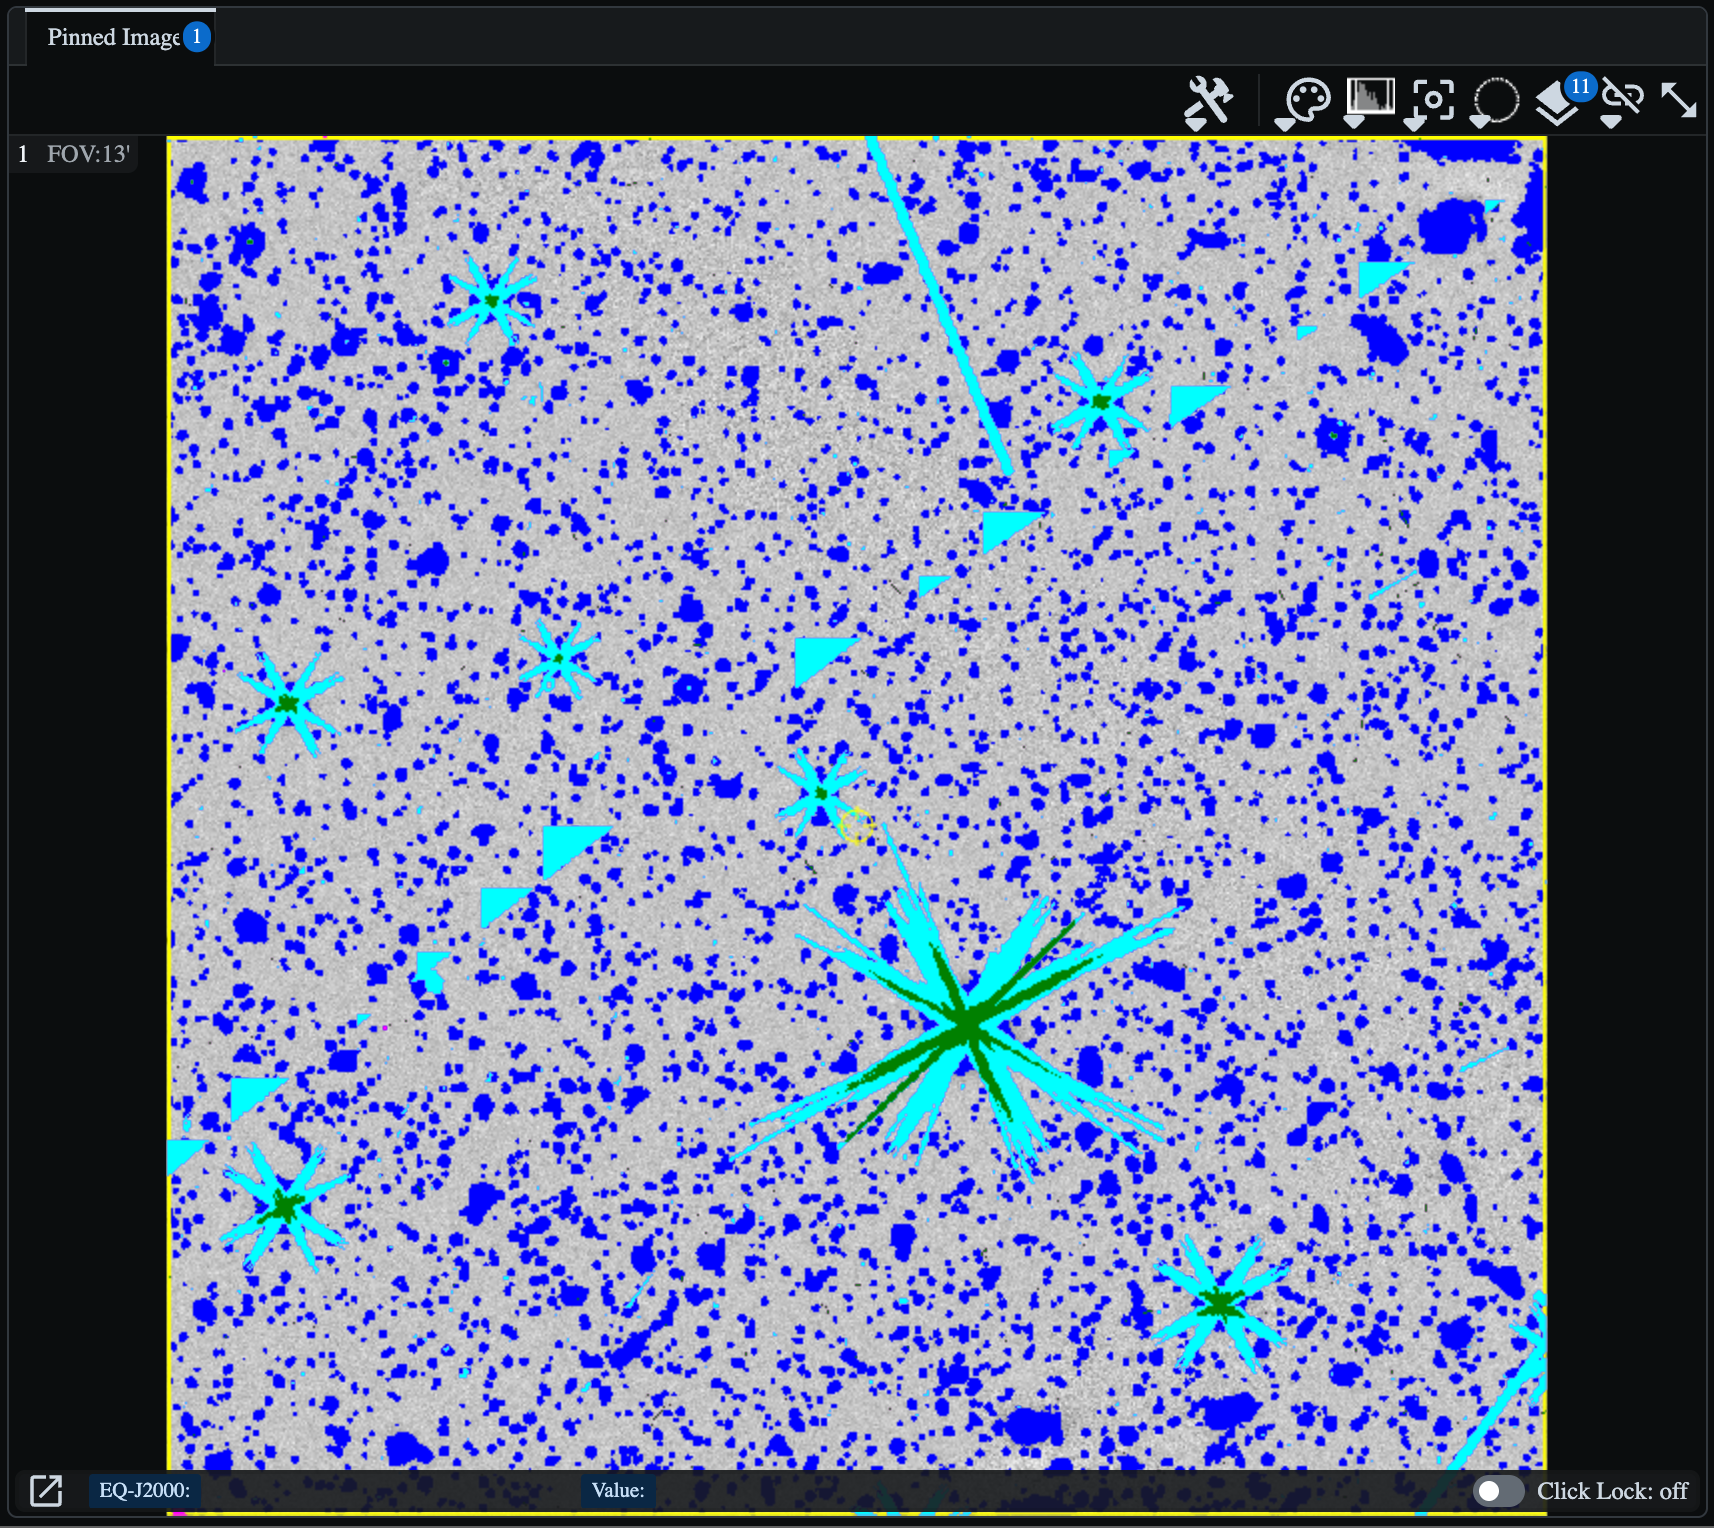

</div>

> **Figure 1:** The mask plane of the r-band `deep_coadd` image for tract 5063, patch 15. The colors correspond to an informative mask flag value (Section 3.3). A large fraction of the pixels have a color (have a nonzero mask value).

### 3.1. Image plane

Sky pixel data in units of nJy (nanojanskys).

The background has been subtracted so values can be negative.

Extract the `image` data from the `deep_coadd`, and convert it to an array.

In [ ]:
image = deep_coadd.image
image_array = image.array

Option to show the `image` and the `image_array`.

In [ ]:
# image

In [ ]:
# image_array

Print statistics on the `image_array`.

In [ ]:
print(image_array.min())
print(image_array.mean())
print(image_array.max())

Display the `image` in Firefly frame 2.

In [ ]:
afw_display = afwDisplay.Display(frame=2)
afw_display.mtv(image)

Mouse-over display frame 2.
The `image` plane contains less information than the full `CellCoadd`, but nonetheless displays coordinates in RA, Dec, as it does carry a WCS.

### 3.2. Variance plane

Uncertainty (noise) in the sky pixel data in units of nJy^2 (nanojanskys squared).

Values are always positive.

Extract the `variance` and `variance_array`.

In [ ]:
variance = deep_coadd.variance
variance_array = variance.array

Print statistics on the `variance_array`.

In [ ]:
print(variance_array.min())
print(variance_array.mean())
print(variance_array.max())

The mean and maximum values printed to the screen are `inf` (infinity). This is because masked pixels (e.g., the saturated pixels at the centers of bright stars) can have no data in the `deep_coadd`, which causes the variance for those pixels to be infinite.

Flag the pixels with `inf` values, count how many there are, and recalculate statistics with those pixels removed.

In [ ]:
inf_variance = (variance_array == np.inf)
print(f"Number of pixels with infinite variance: {np.sum(inf_variance)}")

print("\nStatistics without inf pixels:")
print(variance_array[~inf_variance].min())
print(variance_array[~inf_variance].mean())
print(variance_array[~inf_variance].max())

Display the `variance`. Note that the default auto-scaling of the image stretch will cause the image to look "blank." Change the stretch (to, for example, "Z Scale Linear Stretch") to see detail in the variance image.

In [ ]:
afw_display = afwDisplay.Display(frame=3)
afw_display.mtv(variance)

### 3.3. Mask plane

An integer bitmask of representative flag values that indicate processing status or issues, similar to the [SDSS bitmasks](https://www.sdss4.org/dr17/algorithms/bitmasks/).

Extract the `mask`.

In [ ]:
mask = deep_coadd.mask
mask_array = mask.array

Mask keys (names) are defined by the `mask`
and interpreted as colors by `afw_display`.

Print the list of mask keys and their descriptions.

In [ ]:
print(mask.schema)

Display the mask in Firefly frame 4.

In [ ]:
afw_display = afwDisplay.Display(frame=4)
afw_display.mtv(mask)

The colors are different because the Firefly display interprets the pixel values as flux values (mouse-over and see).

Set the mask transparency to opaque to see the same colors as in frame 1.

In [ ]:
afw_display.setMaskTransparency(0)

Set all mask key names to transparent except the "DETECTED" mask bit.

In [ ]:
afw_display.setMaskTransparency(100)
afw_display.setMaskTransparency(0, 'DETECTED')

Option to print a list of the mask planes and the number of pixels with each mask plane set.

In [ ]:
# for plane in mask.schema:
#     print(plane.name, np.sum(mask.get(plane.name)))

### 3.4. Background

Coadds have a final round of background subtraction applied (in addition to the background subtraction that was already applied to each of the input visits). Extract the `backgrounds` dict and examine the contents.

In [ ]:
backgrounds = deep_coadd.backgrounds

for key in backgrounds.keys():
    print(key)

Print the description of each background type to the screen.

In [ ]:
bg_obj = deep_coadd.backgrounds['object']
bg_pretty = deep_coadd.backgrounds['pretty']

print("object:\n", bg_obj.description)
print('\n')
print("pretty:\n", bg_pretty.description)

Render the backgrounds as images and display them.

In [ ]:
bg_obj_image = bg_obj.field.render()
bg_pretty_image = bg_pretty.field.render()

In [ ]:
afw_display = afwDisplay.Display(frame=3)
afw_display.mtv(bg_obj_image)

afw_display = afwDisplay.Display(frame=4)
afw_display.mtv(bg_pretty_image)

Make a copy of the `deep_coadd`, then use the `apply_background` method to restore some of the background that is often oversubtracted by the default behavior. Display this "restored" `pretty_coadd` in frame 1.

In [ ]:
pretty_coadd = deep_coadd.copy()
pretty_coadd.apply_background('pretty')

In [ ]:
afw_display = afwDisplay.Display(frame=1)
afw_display.mtv(pretty_coadd)

Use the Image alignment drop-down in Firefly to lock the images by pixel origin, then examine various regions of the images to compare the `pretty_coadd` (now in frame 1) to the `deep_coadd` image (in frame 2) and the backgrounds in frames 3 and 4.

Clean up.

In [ ]:
del image, image_array, variance, variance_array, mask, mask_array, pretty_coadd

## 4. Image attributes

### 4.1. Cell-based coadds

#### 4.1.1. Input visits

Information about the input visits that contributed to the `deep_coadd`.

The `deep_coadd` images are made up of a grid of 22x22 150-pixel "cells", within which the PSF may be considered "edge-free" (meaning it was created in a way that avoids any discontinuities). The cells are created separately, then stitched together into a `deep_coadd`. Thus the set of inputs for each cell can be slightly different.

Get the provenance info about each cell and inspect it. Cells are identified by indices _i_ and _j_.

In [ ]:
contrib = deep_coadd.provenance.contributions.to_pandas()

In [ ]:
contrib

Make a histogram of the number of inputs contributing to each cell. The `pandas` "groupby" function makes it easy to group combinations of _ij_ indices.

In [ ]:
plt.hist(contrib.groupby(['cell_i', 'cell_j']).count()['visit'], bins=np.arange(11, 33, 1.0),
         histtype='step')
plt.minorticks_on()
plt.xlabel('number of input visits per cell')
plt.ylabel('number of cells')
plt.show()

> **Figure 2:** Histogram showing the number of input visits contributing to each cell of the `CellCoadd`.

Get the list of input images that were combined to generate
the `deep_coadd`. Note: this list contains all inputs that contributed anywhere in the patch.

Display the first 3 rows of the inputs table.

In [ ]:
inputs = deep_coadd.provenance.inputs
print(f"Number of visits contributing to coadd: {len(inputs)}")
inputs[:3]

Make a spatial plot in tract _xy_ coordinates, color-coding each cell based on the number of input visits that contributed to that cell's coadd.

In [ ]:
unique_combinations = contrib[['cell_i', 'cell_j']].drop_duplicates()
ninputs = []
fig, ax = plt.subplots(figsize=(7, 7))

ninputs = contrib.groupby(['cell_i', 'cell_j']).size().to_numpy()

normal = plt.Normalize(np.min(ninputs), np.max(ninputs))
cmap = plt.cm.viridis
c = cmap(normal(ninputs))

patches = []

for i in range(len(unique_combinations)):
    cell_i = unique_combinations.iloc[i]['cell_i']
    cell_j = unique_combinations.iloc[i]['cell_j']
    pick_cell = (contrib['cell_i'] == cell_i) & (contrib['cell_j'] == cell_j)
    cell_bbox = deep_coadd.grid.bbox_of(CellIJ(cell_i, cell_j))
    patches.append(plt.Rectangle((cell_bbox.x.start, cell_bbox.y.start),
                                 150, 150, facecolor=c[i], fill=True))

col = PatchCollection(patches)
col.set(array=ninputs, cmap=cmap)

ax.add_collection(col)
ax.autoscale()
fig.colorbar(col, label='number of inputs')
ax.set_aspect('equal')

plt.xlabel('tract x (pix)')
plt.ylabel('tract y (pix)')
plt.show()

#### 4.1.2. Info about the cells

Explore the cell `grid` associated with the `deep_coadd` to learn how to access cell information.

First, extract the xy coordinate of the patch corner, `yx0`.

In [ ]:
xy0 = deep_coadd.yx0

Extract the grid indices of the cell corresponding to an _xy_ coordinate, remembering to offset to tract _xy_.

In [ ]:
xcoord = 1914 + xy0.x
ycoord = 1200 + xy0.y
print(f"x: {xcoord}, y: {ycoord}")

cij = deep_coadd.grid.index_of(x=xcoord, y=ycoord)
print(cij)

Extract the bounding box of the cell indices retrieved above.

In [ ]:
deep_coadd.grid.bbox_of(cij)

Print the grid size, then the dict of overall parameters defining the grid.

In [ ]:
deep_coadd.grid.grid_size

In [ ]:
grid_dict = deep_coadd.grid.model_dump()

for key in grid_dict.keys():
    print(key, grid_dict[key], '\n')

In [ ]:
del inputs, grid_dict, xy0, xcoord, ycoord

### 4.2. World Coordinate System (WCS)

The reference system that maps pixel coordinate (x, y) to sky coordinate (RA, Dec).

#### 4.2.1. `sky_projection`

There are multiple encodings of the mapping between sky and pixel coordinates. The most precise version is the `sky_projection`. Retrieve the `sky_projection`.

In [ ]:
wcs = deep_coadd.sky_projection

Convert pixel coordinates to sky coordinates, and vice versa.

In [ ]:
coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
xy = wcs.sky_to_pixel(coord)
coord

In [ ]:
print(xy)

Always pass xy values in tract coordinates when converting from pixel to sky with `sky_projection`.

In [ ]:
xy2 = (15000, 4300)
print("x, y in tract coordinates: ", xy2[0], xy2[1])
print("Corner coordinates of patch: ", deep_coadd.yx0)
print("x, y in patch coordinates: ", xy2[0]-deep_coadd.yx0.x, xy2[1]-deep_coadd.yx0.y)
coord2 = wcs.pixel_to_sky(x=xy2[0], y=xy2[1])

In [ ]:
print(coord2)

#### 4.2.2. astropy_wcs

For users' convenience, an Astropy-compatible version of the WCS is also provided.

In [ ]:
wcs_astropy = deep_coadd.astropy_wcs

Convert the `SkyCoord` from the previous section ("coord2") to xy using the Astropy WCS, and compare the results to see that Astropy returns xy in local (patch) pixel values.

In [ ]:
print("Input xy: ", xy2)
xy2_astropy = wcs_astropy.world_to_pixel(coord2)
print("Output xy: ", xy2_astropy)
print("Output xy in tract coords: ",
      xy2_astropy.x+deep_coadd.yx0.x,
      xy2_astropy.y+deep_coadd.yx0.y)

Apply the Astropy `pixel_to_world` conversion, remembering to pass xy coordinates in local (patch) coordinates.

In [ ]:
coord2_astropy = wcs_astropy.pixel_to_world(xy2[0]-deep_coadd.yx0.x,
                                            xy2[1]-deep_coadd.yx0.y)
print(coord2_astropy)

The RA, Dec coordinate agrees with the result from the previous section.

#### 4.2.3. fits_wcs

There is also a WCS in standard FITS format, provided as `fits_wcs`. For `deep_coadd` images this WCS is an exact representation of the LSST WCS for the image, but for other image types it may be an approximation to the WCS.

Read this WCS and print it to the screen.

In [ ]:
wcs_fits = deep_coadd.fits_wcs

In [ ]:
wcs_fits

Print the object's associated methods to confirm that it also includes conversions between sky to pixel coordinates.

In [ ]:
dir(wcs_fits)

In [ ]:
del xy, xy2, coord, coord2

### 4.3. Bounding box (corners)

The bounding box defines the extent (corners) of the image.

Get the bounding box.

In [ ]:
bbox = deep_coadd.bbox

Print the `deep_coadd` corners in pixels and sky coordinates.

In [ ]:
bbox.min.x

In [ ]:
corners = ((bbox.min.x, bbox.min.y),
           (bbox.min.x, bbox.max.y),
           (bbox.max.x, bbox.max.y),
           (bbox.max.x, bbox.min.y))
for corner in corners:
    print("corner (x, y): ", corner, '\n', wcs.pixel_to_sky(x=corner[0], y=corner[1]))

Check if pixel values are within the bounding box.

In [ ]:
assert bbox.contains(x=100, y=100) is False
print(bbox.contains(x=100, y=100))
assert bbox.contains(x=16000, y=4000) is True
print(bbox.contains(x=16000, y=4000))

Check if sky coordinates are within the bounding box.

In [ ]:
coord = SkyCoord(ra=63.0*u.deg, dec=-38.0*u.deg, frame='icrs')
coord2 = SkyCoord(ra=53.0*u.deg, dec=-28.1*u.deg, frame='icrs')
xy = wcs.sky_to_pixel(coord)
xy2 = wcs.sky_to_pixel(coord2)
print(bbox.contains(x=xy[0], y=xy[1]))
print(bbox.contains(x=xy2[0], y=xy2[1]))

Clean up.

In [ ]:
del corners, coord, coord2, xy

### 4.4. Point spread function (PSF)

The PSF is the empirical estimate of the shape of a point source as a function of position in the image.
The PSF encapsulates all of the atmospheric and optical effects that blur point sources into their measured shapes.

Get the PSF.

In [ ]:
psf = deep_coadd.psf

At pixel coordinates x, y = 16000, 4000, compute the PSF and display it in frame 5.

In [ ]:
xy = (16000, 4000)
psf_image = psf.compute_kernel_image(x=xy[0], y=xy[1])
afw_display = afwDisplay.Display(frame=5)
afw_display.mtv(psf_image)

Clean up.

In [ ]:
del psf, xy, psf_image

## 5. Detected objects

In general the TAP service is the recommended access mechanism for catalog data.

However, in the case where *all* the objects (or sources, for `visit_images`) detected in a given image are desired, the Butler offers a quick way to retrieve them.

Get the tract and patch for the `deep_coadd`.

In [ ]:
ref = dataset_refs[0]
dataId = ref.dataId
use_tract = dataId.get('tract')
use_patch = dataId.get('patch')
print(use_tract, use_patch)

Show that the only dimension for the `object` dataset type is tract.

In [ ]:
butler.registry.queryDatasetTypes('object')

Since a `butler.get` call on the `object` table will return
all of the objects in a *tract*, not the single patch of
the `deep_coadd`, return only a select few of the >1000
columns and include column `patch`.

In [ ]:
use_columns = ['objectId', 'patch',
               'coord_ra', 'coord_dec']

Retrive the `object` table as `objects`.

In [ ]:
objects = butler.get('object', tract=use_tract, skymap='lsst_cells_v2',
                     parameters={'columns': use_columns})

Print the number of sources in the detector for this `deep_coadd` (for its `patch`).

In [ ]:
tx = np.where(objects['patch'] == use_patch)[0]
print(len(tx))

Option to show the table.

In [ ]:
# objects[tx]

Redisplay the `deep_coadd` in frame 1 with no mask.

In [ ]:
afw_display = afwDisplay.Display(frame=1)
afw_display.mtv(deep_coadd)
afw_display.setMaskTransparency(100)

Overplot sources in the `deep_coadd` with orange circles.

In [ ]:
sc_patch = SkyCoord(ra=objects['coord_ra']*u.deg,
                    dec=objects['coord_dec']*u.deg,
                    frame='icrs')

with afw_display.Buffering():
    for i in tx:
        xy_tmp = wcs.sky_to_pixel(sc_patch[i])
        afw_display.dot('o',
                        xy_tmp.x,
                        xy_tmp.y,
                        size=20, ctype='orange')

Notice that no objects near the edges are marked with an orange circle; they are listed as belonging to the adjacent patch.

Clean up.

In [ ]:
del ref, dataId, use_tract, use_patch, use_columns, objects, tx
del dataset_refs, deep_coadd